In [4]:
import osmnx as ox
import pandas as pd

print("서울 도로 데이터 다운로드 중... (1~2분 소요)")

# 1. 데이터 다운로드
cf = '["highway"~"trunk|primary|secondary"]'
G = ox.graph_from_place("Seoul, South Korea", custom_filter=cf, network_type="drive")
edges = ox.graph_to_gdfs(G, nodes=False)

# 2. 도로 위계(highway) 컬럼 정제 및 라벨 맵핑
# 값이 리스트로 올 경우 첫 번째 값만 추출하여 'highway_clean' 컬럼 생성
edges['highway_clean'] = edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)

label_map = {
    "trunk":     "국도/주간선 (trunk)",
    "primary":   "주요 간선도로 (primary)",
    "secondary": "보조 간선도로 (secondary)",
}

# 정제된 영문 위계를 바탕으로 한글 라벨 컬럼 추가
edges['highway_label'] = edges['highway_clean'].map(label_map).fillna("기타")


# 3. 차선 수(lanes) 정제하여 숫자형 컬럼 추가
def clean_lanes(x):
    # 1단계: 값이 리스트 형태면 먼저 첫 번째 값을 추출하여 단일 값으로 만듦
    if isinstance(x, list):
        if len(x) > 0:
            x = x[0]
        else:
            return 2.0

    # 2단계: 단일 값이 된 상태에서 결측치(NaN) 검사
    if pd.isna(x):
        return 2.0  # 결측치는 기본값 2차선으로 설정

    # 3단계: 실수형(Float)으로 변환
    try:
        return float(x)
    except (ValueError, TypeError):
        return 2.0  # 변환 불가능한 예외 텍스트인 경우 기본값 처리

# 'lanes' 컬럼이 존재하는지 확인 후 숫자형 컬럼 'lanes_num' 추가
if 'lanes' in edges.columns:
    edges['lanes_num'] = edges['lanes'].apply(clean_lanes)
else:
    edges['lanes_num'] = 2.0


# 4. 결과 확인
print("\n데이터 정제 및 컬럼 추가 완료!")
print("=" * 60)
print(edges[['highway', 'highway_clean', 'highway_label', 'lanes', 'lanes_num']].head())

서울 도로 데이터 다운로드 중... (1~2분 소요)


/opt/miniconda3/envs/engineering/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/engineering/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/miniconda3/envs/engineering/lib/python3.11/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/opt/miniconda3/envs/engineering/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/miniconda3/envs/engineering/lib/python3.11/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)



데이터 정제 및 컬럼 추가 완료!
                                 highway   highway_clean        highway_label  \
u         v          key                                                        
287287152 8495290882 0           primary         primary    주요 간선도로 (primary)   
          295486169  0           primary         primary    주요 간선도로 (primary)   
          7838649559 0    secondary_link  secondary_link                   기타   
287288045 1943131935 0         secondary       secondary  보조 간선도로 (secondary)   
          1943131877 0         secondary       secondary  보조 간선도로 (secondary)   

                         lanes  lanes_num  
u         v          key                   
287287152 8495290882 0     NaN        2.0  
          295486169  0     NaN        2.0  
          7838649559 0     NaN        2.0  
287288045 1943131935 0     NaN        2.0  
          1943131877 0       5        5.0  


In [7]:
edges['lanes_num'].isna().sum()

np.int64(0)

In [8]:
edges['highway_clean'].unique()

<ArrowStringArray>
['primary', 'secondary_link', 'secondary', 'trunk', 'trunk_link',
 'primary_link']
Length: 6, dtype: str

In [10]:
edges = edges.drop(columns = ['bridge','lanes','maxspeed','junction','width','tunnel','access'])

/var/folders/pk/6tlj8j4n5b90lwc_4d4rr51m0000gn/T/ipykernel_71542/3664654495.py:49: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pk/6tlj8j4n5b90lwc_4d4rr51m0000gn/T/ipykernel_71542/3664654495.py:49: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pk/6tlj8j4n5b90lwc_4d4rr51m0000gn/T/ipykernel_71542/3664654495.py:49: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pk/6tlj8j4n5b90lwc_4d4rr51m0000gn/T/ipykernel_71542/3664654495.py:49: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pk/6tlj8j4n5b90lwc_4d4rr51m0000gn/T/ipykernel_71542/3664654495.py:49: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/pk/6tlj8j4n5b90lwc_4d4rr51m0000gn/T/ipykern

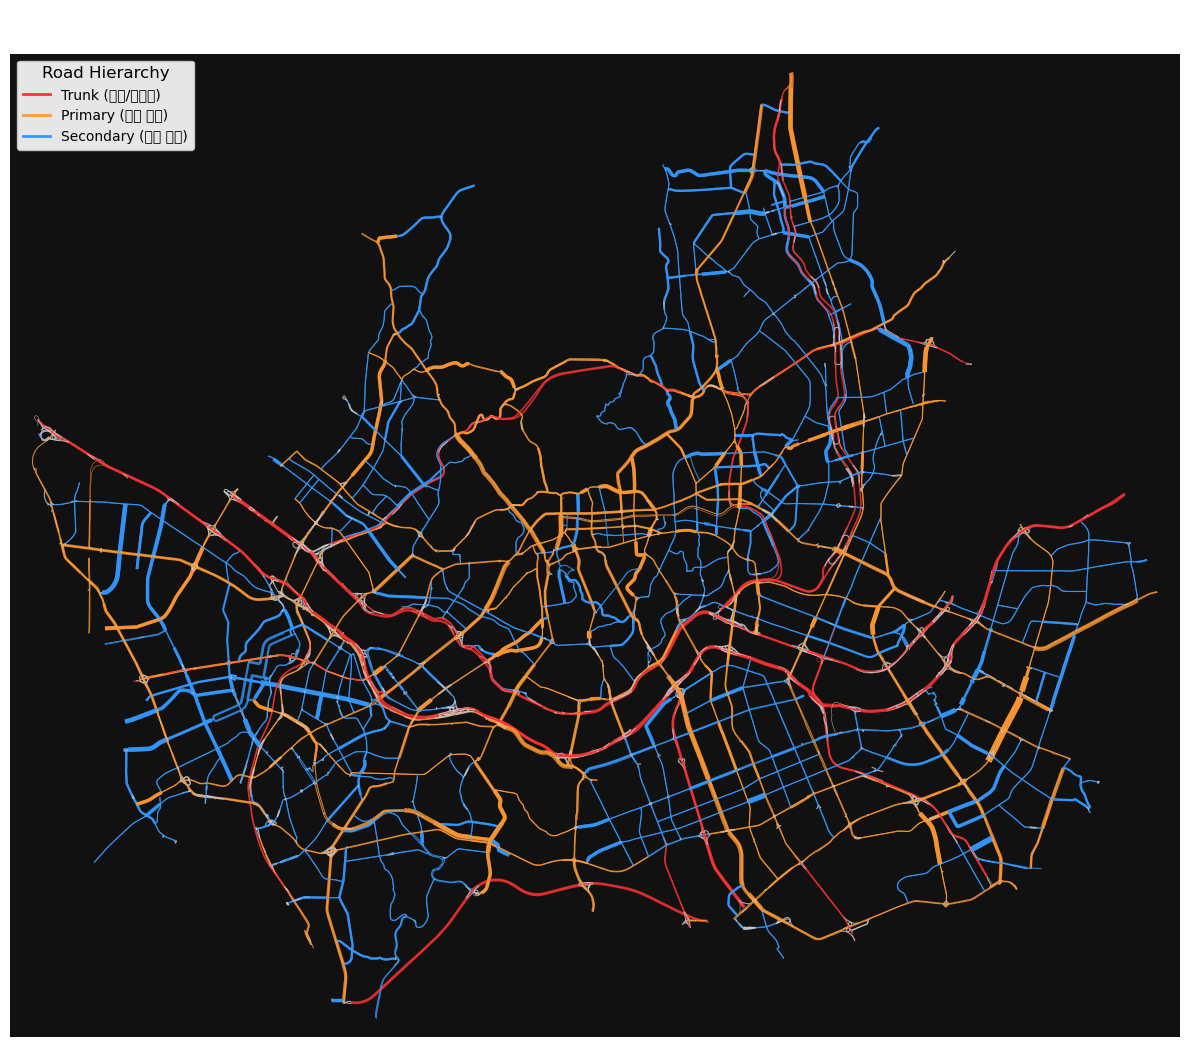

In [14]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
# 2. 도로 위계(highway)에 따른 색상 매핑
# OSM 데이터는 값이 리스트로 올 수 있으므로, 리스트인 경우 첫 번째 값만 추출
edges['highway_type'] = edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)

color_map = {
    "trunk": "#ff3333",      # 국도/주간선: 빨간색
    "primary": "#ff9933",    # 주요 간선: 주황색
    "secondary": "#3399ff"   # 보조 간선: 파란색
}

# 딕셔너리에 없는 값이 들어올 경우를 대비해 기본색(회색) 지정
edge_colors = edges['highway_clean'].map(color_map).fillna("#cccccc")

edge_linewidths = edges['lanes_num'] * 0.4  # 차선당 0.4px 굵기 적용

# 4. 지도 시각화 (그래프 그리기)
fig, ax = ox.plot_graph(
    G,
    node_size=0,                          # 교차로 점 숨기기
    edge_color=edge_colors.tolist(),      # 매핑한 색상 리스트 적용
    edge_linewidth=edge_linewidths.tolist(), # 매핑한 두께 리스트 적용
    edge_alpha=0.8,                       # 투명도
    bgcolor='#111111',                    # 배경색 (다크 테마)
    show=False,
    close=False,
    figsize=(12, 12)                      # 출력 이미지 크기
)

# 5. 범례(Legend) 추가
legend_elements = [
    mlines.Line2D([0], [0], color='#ff3333', lw=2, label='Trunk (국도/주간선)'),
    mlines.Line2D([0], [0], color='#ff9933', lw=2, label='Primary (주요 간선)'),
    mlines.Line2D([0], [0], color='#3399ff', lw=2, label='Secondary (보조 간선)')
]

ax.legend(
    handles=legend_elements, 
    loc='upper left', 
    facecolor='white', 
    framealpha=0.9,
    title="Road Hierarchy",
    title_fontsize=12,
    fontsize=10
)

plt.title("Seoul Major Road Network (Mapped by Hierarchy & Lanes)", fontsize=15, color='white', pad=20)
plt.tight_layout()
plt.show()

In [19]:
edges

osmid  \
u           v           key                                      
287287152   8495290882  0                            218655250   
            295486169   0      [26965306, 26965302, 406000767]   
            7838649559  0                            226905209   
287288045   1943131935  0                             26259445   
            1943131877  0                            393310531   
...                                                        ...   
13821634895 13821634892 0                            183895365   
            13566284583 0                            946016872   
13821643825 3835707014  0                           1072173601   
            436831747   0    [712243712, 712243713, 668807298]   
            13566334148 0                           1478779812   

                                    highway  name  ref  oneway reversed  \
u           v           key                                               
287287152   8495290882  0           primary  고산자로   51   False     True   
            295486169   0           primary  고산자로   51    True    False   
            7838649559  0    secondary_link  고산자로  NaN    True    False   
287288045   1943131935  0         secondary   무학로  NaN   False    False   
            1943131877  0         secondary   무학로  NaN   False     True   
...                                     ...   ...  ...     ...      ...   
13821634895 13821634892 0           primary   화랑로   20    True    False   
            13566284583 0           primary   동일로    3    True    False   
13821643825 3835707014  0         secondary   상계로  NaN   False     True   
            436831747   0         secondary   상계로  NaN   False    False   
            13566334148 0           primary   동일로    3    True    False   

                                 length  \
u           v           key               
287287152   8495290882  0     18.496648   
            295486169   0    748.121888   
            7838649559  0    197.493922   
287288045   1943131935  0      2.885364   
            1943131877  0     39.840708   
...                                 ...   
13821634895 13821634892 0     13.790863   
            13566284583 0     17.755086   
13821643825 3835707014  0     14.956433   
            436831747   0    574.012261   
            13566334148 0    570.070613   

                                                                      geometry  \
u           v           key                                                      
287287152   8495290882  0    LINESTRING (127.03458 37.55393, 127.03453 37.5...   
            295486169   0    LINESTRING (127.03458 37.55393, 127.03464 37.5...   
            7838649559  0    LINESTRING (127.03458 37.55393, 127.03449 37.5...   
287288045   1943131935  0    LINESTRING (127.02953 37.58266, 127.02953 37.5...   
            1943131877  0    LINESTRING (127.02953 37.58266, 127.0296 37.5823)   
...                                                                        ...   
13821634895 13821634892 0    LINESTRING (127.0757 37.61772, 127.07556 37.61...   
            13566284583 0    LINESTRING (127.0757 37.61772, 127.07566 37.61...   
13821643825 3835707014  0    LINESTRING (127.06035 37.65564, 127.06019 37.6...   
            436831747   0    LINESTRING (127.06035 37.65564, 127.06042 37.6...   
            13566334148 0    LINESTRING (127.06035 37.65564, 127.06026 37.6...   

                              highway_clean        highway_label  lanes_num  \
u           v           key                                                   
287287152   8495290882  0           primary    주요 간선도로 (primary)        2.0   
            295486169   0           primary    주요 간선도로 (primary)        2.0   
            7838649559  0    secondary_link                   기타        2.0   
287288045   1943131935  0         secondary  보조 간선도로 (secondary)        2.0   
            1943131877  0         secondary  보조 간선도로 (secondary)        5.0   
...                                     ..

In [21]:
import geopandas as gpd
import pandas as pd

# ── 1. GeoPackage에서 join_key와 GVI만 추출 ──────────────────────────────────
gdf = gpd.read_file("/Users/judetak/Desktop/DDUDL랩실 인턴/seoul_street_clusters_final.gpkg")
gvi_df = gdf[["join_key", "GVI"]].copy()



In [22]:
# ── 2. join_key (u_v_osmid) → u, v 분리 ────────────────────────────────────
# join_key 형식: "u_v_osmid"  →  split 후 앞 두 값만 사용
split_cols = gvi_df["join_key"].str.split("_", expand=True)
gvi_df["u"] = split_cols[0].astype("int64")
gvi_df["v"] = split_cols[1].astype("int64")

gvi_df = gvi_df.drop(columns=["join_key"])

print("GVI 테이블 샘플:")
print(gvi_df.head())
print(f"  rows: {len(gvi_df):,}")


GVI 테이블 샘플:
        GVI            u            v
0  1.904019  10000866582  10000866592
1  1.904019  10000866582   4190702221
2  1.539381  10000866582   9411623407
3 -0.463484  10000866583  10000866585
4 -0.463484  10000866583  10000866592
  rows: 149,186


In [23]:
# ── 3. edges와 merge ────────────────────────────────────────────────────────
# edges는 osmnx 로드 결과이므로 MultiIndex (u, v, key) 또는
# reset_index() 된 DataFrame 두 가지 경우를 모두 처리한다.

# edges가 MultiIndex인 경우 reset
if isinstance(edges.index, pd.MultiIndex):
    edges_flat = edges.reset_index()   # u, v, key 컬럼이 생김
else:
    edges_flat = edges.copy()

# GVI를 (u, v) 기준으로 left-join
edges_merged = edges_flat.merge(gvi_df, on=["u", "v"], how="left")

# 필요하면 원래 MultiIndex 복원
# edges_merged = edges_merged.set_index(["u", "v", "key"])

print("\nMerge 완료 샘플:")
print(edges_merged[["u", "v", "GVI"]].head(10))
print(f"  전체 행: {len(edges_merged):,}")
print(f"  GVI 매칭 수: {edges_merged['GVI'].notna().sum():,}")
print(f"  GVI 미매칭 수: {edges_merged['GVI'].isna().sum():,}")


Merge 완료 샘플:
           u           v       GVI
0  287287152  8495290882       NaN
1  287287152   295486169 -0.692170
2  287287152  7838649559 -0.198700
3  287288045  1943131935       NaN
4  287288045  1943131877       NaN
5  287288045  1943131962 -0.020123
6  287304613  1132441056 -0.635619
7  287319177   436837770 -0.485711
8  287319177  5194568310       NaN
9  287521281  2517102158  0.907885
  전체 행: 11,086
  GVI 매칭 수: 5,596
  GVI 미매칭 수: 5,490


In [26]:
import geopandas as gpd
import pandas as pd

# GVI 로드
gvi_df = gdf[["join_key", "GVI"]].copy()
gvi_df["u"] = gvi_df["join_key"].str.split("_").str[0].astype("int64")
gvi_df["v"] = gvi_df["join_key"].str.split("_").str[1].astype("int64")
gvi_df = gvi_df.drop(columns=["join_key"])

# (u,v) 중복 시 GVI 평균으로 집계
gvi_df = gvi_df.groupby(["u", "v"], as_index=False)["GVI"].mean()

# edges 전처리
edges_flat = edges.reset_index() if isinstance(edges.index, pd.MultiIndex) else edges.copy()

# edges의 (u,v)가 GVI에 존재하는지 확인
edges_uv = set(zip(edges_flat["u"], edges_flat["v"]))
gvi_uv   = set(zip(gvi_df["u"], gvi_df["v"]))

print("edges (u,v) 수:", len(edges_uv))
print("GVI   (u,v) 수:", len(gvi_uv))
print("교집합:", len(edges_uv & gvi_uv))
print("edges에만 있는 (u,v):", len(edges_uv - gvi_uv))  # 이게 NaN의 원인

edges (u,v) 수: 10996
GVI   (u,v) 수: 148323
교집합: 5543
edges에만 있는 (u,v): 5453


In [29]:
merged

,u,v,key,osmid,highway,name,ref,oneway,reversed,length,geometry,highway_clean,highway_label,lanes_num,highway_type,GVI
0,287287152,8495290882,0,218655250,primary,고산자로,51,False,True,18.496648,"LINESTRING (127.03458 37.55393, 127.03453 37.5...",primary,주요 간선도로 (primary),2.0,primary,NaN
1,287287152,295486169,0,"[26965306, 26965302, 406000767]",primary,고산자로,51,True,False,748.121888,"LINESTRING (127.03458 37.55393, 127.03464 37.5...",primary,주요 간선도로 (primary),2.0,primary,-0.69217
2,287287152,7838649559,0,226905209,secondary_link,고산자로,NaN,True,False,197.493922,"LINESTRING (127.03458 37.55393, 127.03449 37.5...",secondary_link,기타,2.0,secondary_link,-0.19870
3,287288045,1943131935,0,26259445,secondary,무학로,NaN,False,False,2.885364,"LINESTRING (127.02953 37.58266, 127.02953 37.5...",secondary,보조 간선도로 (secondary),2.0,secondary,NaN
4,287288045,1943131877,0,393310531,secondary,무학로,NaN,False,True,39.840708,"LINESTRING (127.02953 37.58266, 127.0296 37.5823)",secondary,보조 간선도로 (secondary),5.0,secondary,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11071,13821634895,13821634892,0,183895365,primary,화랑로,20,True,False,13.790863,"LINESTRING (127.0757 37.61772, 127.07556 37.61...",primary,주요 간선도로 (primary),4.0,primary,NaN
11072,13821634895,13566284583,0,946016872,primary,동일로,3,True,False,17.755086,"LINESTRING (127.0757 37.61772, 127.07566 37.61...",primary,주요 간선도로 (primary),2.0,primary,NaN
11073,13821643825,3835707014,0,1072173601,secondary,상계로,NaN,False,True,14.956433,"LINESTRING (127.06035 37.65564, 127.06019 37.6...",secondary,보조 간선도로 (secondary),2.0,secondary,NaN
11074,13821643825,436831747,0,"[712243712, 712243713, 668807298]",secondary,상계로,NaN,False,False,574.012261,"LINESTRING (127.06035 37.65564, 127.06042 37.6...",secondary,보조 간선도로 (secondary),2.0,secondary,NaN


In [31]:
edges_flat = edges.reset_index()

# 정방향 merge
merged = edges_flat.merge(gvi_df, on=["u", "v"], how="left")
gvi_df = gdf[["join_key", "GVI"]].copy()
gvi_df["u"] = gvi_df["join_key"].str.split("_").str[0].astype("int64")
gvi_df["v"] = gvi_df["join_key"].str.split("_").str[1].astype("int64")
gvi_df = gvi_df.drop(columns=["join_key"])
gvi_df = gvi_df.groupby(["u", "v"], as_index=False)["GVI"].mean()
# reversed: u↔v 뒤집은 GVI 테이블
merged = edges_flat.merge(gvi_df, on=["u", "v"], how="left")
gvi_reversed = gvi_df.rename(columns={"u": "v", "v": "u"})

# NaN인 행만 따로 reversed merge
nan_mask = merged["GVI"].isna()
filled = merged[nan_mask].drop(columns=["GVI"]).merge(
    gvi_reversed, on=["u", "v"], how="left"
)

# index 맞춰서 채우기
merged.loc[nan_mask, "GVI"] = filled["GVI"].values

print(f"GVI 매칭 수: {merged['GVI'].notna().sum():,}")
print(f"GVI 미매칭 수: {merged['GVI'].isna().sum():,}")

GVI 매칭 수: 6,454
GVI 미매칭 수: 4,622


In [32]:
# NaN인 edges의 u,v 샘플
nan_edges = merged[merged["GVI"].isna()][["u", "v"]].head(20)
print("NaN edges 샘플:")
print(nan_edges.to_string())

# 이 u,v 값들이 GVI에 존재하는지 확인 (u나 v 중 하나라도)
sample_u = nan_edges["u"].iloc[0]
sample_v = nan_edges["v"].iloc[0]

print(f"\n첫 번째 NaN edge: u={sample_u}, v={sample_v}")
print("GVI에서 해당 u 포함 행:")
print(gvi_df[(gvi_df["u"] == sample_u) | (gvi_df["v"] == sample_u)])
print("GVI에서 해당 v 포함 행:")
print(gvi_df[(gvi_df["u"] == sample_v) | (gvi_df["v"] == sample_v)])

NaN edges 샘플:
            u            v
8   287319177   5194568310
13  287710035   7068765379
14  295486057    414685338
20  298310984   4168324392
21  298310984    436794166
24  355173169   8553549980
25  387153848   2139941819
27  387153879    436795699
33  387153896  13672396779
34  387153896  13672396779
36  387154516    387154698
37  387154518   2753700671
42  387154700  13695195755
43  387154705   2753700728
44  387154712    387154516
46  387154717    436760148
47  387154721   2139941839
48  387154721    387154319
52  414683159    436538549
54  414683163    436830632

첫 번째 NaN edge: u=287319177, v=5194568310
GVI에서 해당 u 포함 행:
                 u           v       GVI
14       287319177   436837770 -0.485711
15       287319177  4680427789  0.170694
1147     436835244   287319177 -0.286938
110335  5973684182   287319177 -0.280097
GVI에서 해당 v 포함 행:
                 u           v       GVI
38541   3809204293  5194568310 -0.678045
105347  5194568310  3809204344 -0.551636
110331  5973684

In [34]:
import geopandas as gpd
import pandas as pd

# GVI 로드
gvi_df = gdf[["join_key", "GVI", "geometry"]].copy()
gvi_df["u"] = gvi_df["join_key"].str.split("_").str[0].astype("int64")
gvi_df["v"] = gvi_df["join_key"].str.split("_").str[1].astype("int64")
gvi_gdf = gpd.GeoDataFrame(gvi_df[["u", "v", "GVI", "geometry"]], crs=gdf.crs)

# edges GeoDataFrame으로 변환
edges_flat = edges.reset_index()
edges_gdf = gpd.GeoDataFrame(edges_flat, geometry="geometry", crs="EPSG:4326")

# CRS 통일
if gvi_gdf.crs != edges_gdf.crs:
    gvi_gdf = gvi_gdf.to_crs(edges_gdf.crs)

# ── 1단계: (u, v) exact match ───────────────────────────────
gvi_clean = gvi_df[["u", "v", "GVI"]].groupby(["u", "v"], as_index=False)["GVI"].mean()
merged = edges_flat.merge(gvi_clean, on=["u", "v"], how="left")

# reversed 보완
nan_mask = merged["GVI"].isna()
gvi_rev = gvi_clean.rename(columns={"u": "v", "v": "u"})
filled = merged[nan_mask].drop(columns=["GVI"]).merge(gvi_rev, on=["u", "v"], how="left")
merged.loc[nan_mask, "GVI"] = filled["GVI"].values

print(f"exact match 후 - 매칭: {merged['GVI'].notna().sum():,} / 미매칭: {merged['GVI'].isna().sum():,}")

# ── 2단계: geometry 기반 nearest match ────
nan_mask2 = merged["GVI"].isna()
edges_nan = edges_gdf[nan_mask2].copy()

edges_nan_proj = edges_nan.to_crs("EPSG:5179")
gvi_proj = gvi_gdf.to_crs("EPSG:5179")

matched = gpd.sjoin_nearest(
    edges_nan_proj[["geometry"]],  # u,v 제거해서 충돌 방지
    gvi_proj[["GVI", "geometry"]],
    how="left",
    max_distance=30
)

# 1:N 중복 발생 시 첫 번째만 유지 (index 기준)
matched = matched[~matched.index.duplicated(keep="first")]

# index 맞춰서 채우기
merged.loc[nan_mask2, "GVI"] = matched["GVI"]

print(f"geometry match 후 - 매칭: {merged['GVI'].notna().sum():,} / 미매칭: {merged['GVI'].isna().sum():,}")

exact match 후 - 매칭: 6,454 / 미매칭: 4,622
geometry match 후 - 매칭: 11,046 / 미매칭: 30


In [35]:
merged

,u,v,key,osmid,highway,name,ref,oneway,reversed,length,geometry,highway_clean,highway_label,lanes_num,highway_type,GVI
0,287287152,8495290882,0,218655250,primary,고산자로,51,False,True,18.496648,"LINESTRING (127.03458 37.55393, 127.03453 37.5...",primary,주요 간선도로 (primary),2.0,primary,-0.626595
1,287287152,295486169,0,"[26965306, 26965302, 406000767]",primary,고산자로,51,True,False,748.121888,"LINESTRING (127.03458 37.55393, 127.03464 37.5...",primary,주요 간선도로 (primary),2.0,primary,-0.692170
2,287287152,7838649559,0,226905209,secondary_link,고산자로,NaN,True,False,197.493922,"LINESTRING (127.03458 37.55393, 127.03449 37.5...",secondary_link,기타,2.0,secondary_link,-0.198700
3,287288045,1943131935,0,26259445,secondary,무학로,NaN,False,False,2.885364,"LINESTRING (127.02953 37.58266, 127.02953 37.5...",secondary,보조 간선도로 (secondary),2.0,secondary,0.297028
4,287288045,1943131877,0,393310531,secondary,무학로,NaN,False,True,39.840708,"LINESTRING (127.02953 37.58266, 127.0296 37.5823)",secondary,보조 간선도로 (secondary),5.0,secondary,0.154751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11071,13821634895,13821634892,0,183895365,primary,화랑로,20,True,False,13.790863,"LINESTRING (127.0757 37.61772, 127.07556 37.61...",primary,주요 간선도로 (primary),4.0,primary,-0.302076
11072,13821634895,13566284583,0,946016872,primary,동일로,3,True,False,17.755086,"LINESTRING (127.0757 37.61772, 127.07566 37.61...",primary,주요 간선도로 (primary),2.0,primary,-0.273287
11073,13821643825,3835707014,0,1072173601,secondary,상계로,NaN,False,True,14.956433,"LINESTRING (127.06035 37.65564, 127.06019 37.6...",secondary,보조 간선도로 (secondary),2.0,secondary,-0.331710
11074,13821643825,436831747,0,"[712243712, 712243713, 668807298]",secondary,상계로,NaN,False,False,574.012261,"LINESTRING (127.06035 37.65564, 127.06042 37.6...",secondary,보조 간선도로 (secondary),2.0,secondary,0.498241


In [36]:
import geopandas as gpd
import pandas as pd

edges_proj = edges_gdf.to_crs("EPSG:5179")
gvi_proj = gvi_gdf[["GVI", "geometry"]].to_crs("EPSG:5179")

# edges에 버퍼 씌워서 (선분이라 intersect가 안 잡힐 수 있음)
edges_buf = edges_proj.copy()
edges_buf["geometry"] = edges_proj.buffer(15)  # 좌우 15m = 총 30m 폭

# 버퍼와 교차하는 GVI 세그먼트 sjoin
joined = gpd.sjoin(
    edges_buf[["geometry"]],
    gvi_proj,
    how="left",
    predicate="intersects"
)

# edges 인덱스 기준으로 GVI 평균
gvi_mean = joined.groupby(joined.index)["GVI"].mean()

# merged에 반영
merged["GVI"] = merged.index.map(gvi_mean)

print(f"매칭: {merged['GVI'].notna().sum():,} / 미매칭: {merged['GVI'].isna().sum():,}")
print(merged[["u", "v", "GVI"]].head(10))

/opt/miniconda3/envs/engineering/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


매칭: 11,028 / 미매칭: 48
           u           v       GVI
0  287287152  8495290882 -0.506932
1  287287152   295486169 -0.403852
2  287287152  7838649559 -0.294111
3  287288045  1943131935  0.124949
4  287288045  1943131877  0.172190
5  287288045  1943131962 -0.028590
6  287304613  1132441056 -0.559704
7  287319177   436837770 -0.341402
8  287319177  5194568310 -0.432885
9  287521281  2517102158  0.820310


In [39]:
# 미매칭 48건 → 버퍼 점점 키워서 GVI 2개 이상 잡기
nan_mask = merged["GVI"].isna()
edges_nan_proj = edges_proj[nan_mask].copy()

edges_nan_buf = edges_nan_proj.copy()
edges_nan_buf["geometry"] = edges_nan_proj.buffer(200)  # 100m 버퍼로 확장

joined2 = gpd.sjoin(
    edges_nan_buf[["geometry"]],
    gvi_proj[["GVI", "geometry"]],
    how="left",
    predicate="intersects"
)

gvi_nearest2_mean = joined2.groupby(joined2.index)["GVI"].mean()
merged.loc[nan_mask, "GVI"] = merged.loc[nan_mask].index.map(gvi_nearest2_mean)

print(f"최종 - 매칭: {merged['GVI'].notna().sum():,} / 미매칭: {merged['GVI'].isna().sum():,}")

최종 - 매칭: 11,076 / 미매칭: 0


/opt/miniconda3/envs/engineering/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


In [45]:
merged['GVI'].median()

np.float64(-0.15634390406095033)

In [46]:
merged.to_file('서울 도로 위계 및 GVI.gpkg')


In [1]:
import geopandas as gpd

# 1. 데이터 불러오기
road_path = '/Users/judetak/Desktop/DDUDL랩실 인턴/seoul_osm_edges/seoul_road_full_simple_edges.shp'
grid_path = '/Users/judetak/Downloads/grid_pm10_20251001_1000/grid_pm10_20251001_1000.shp'

print("데이터 로딩 중...")
roads = gpd.read_file(road_path)
grids = gpd.read_file(grid_path)

# 메모리 최적화를 위해 그리드 데이터에서 필요한 필드(PM10)와 공간 정보만 남김
if 'PM10' in grids.columns:
    grids = grids[['PM10', 'geometry']]

# 2. 좌표계(CRS) 일치 확인 및 변환
if roads.crs != grids.crs:
    print(f"좌표계 일치화 진행: {grids.crs} -> {roads.crs}")
    grids = grids.to_crs(roads.crs)

# 3. 공간 결합 (Spatial Join) 수행
# how='left': 도로 데이터를 기준으로 유지
# predicate='intersects': 도로가 그리드에 닿거나 걸쳐 있는 경우 결합
print("공간 결합 수행 중 (공간 인덱스 자동 적용)...")
joined_roads = gpd.sjoin(roads, grids, how='left', predicate='intersects')

# 4. 중복 데이터 처리
# 도로가 2개 이상의 그리드에 걸쳐 있으면 데이터(행)가 복제됩니다.
# QGIS의 "가장 큰 중첩 영역" 또는 "첫 번째 위치 피처만 사용"과 같은 1:1 결합을 위해 중복을 제거합니다.
print("중복 도로 구간 처리 중...")
joined_roads = joined_roads[~joined_roads.index.duplicated(keep='first')]

# sjoin 시 자동 생성되는 불필요한 'index_right' 컬럼 제거
if 'index_right' in joined_roads.columns:
    joined_roads = joined_roads.drop(columns=['index_right'])

# 5. 결과 저장
# 대용량 공간 데이터는 SHP보다 처리 속도와 용량 관리에 유리한 GeoPackage(.gpkg) 포맷을 권장합니다.
output_path = '/Users/judetak/Desktop/DDUDL랩실 인턴/seoul_osm_edges/seoul_road_pm10_joined.gpkg'
print(f"결과 저장 중: {output_path}")
joined_roads.to_file(output_path, driver='GPKG')

print("작업이 성공적으로 완료되었습니다!")

데이터 로딩 중...
좌표계 일치화 진행: EPSG:5179 -> EPSG:4326
공간 결합 수행 중 (공간 인덱스 자동 적용)...
중복 도로 구간 처리 중...
결과 저장 중: /Users/judetak/Desktop/DDUDL랩실 인턴/seoul_osm_edges/seoul_road_pm10_joined.gpkg
작업이 성공적으로 완료되었습니다!
